In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

In [2]:
import pandas as pd
import numpy as np
from src.data.loader import load_features, get_features_and_target

df = load_features()

2026-09-23 12:46:32.423 | INFO     | src.data.loader:load_features:15 - Loading features from retailpulse-509504.retailpulse_mart.feature_customer_360 ...
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
2026-09-23 12:46:46.269 | SUCCESS  | src.data.loader:load_features:18 - Loaded 94,989 rows, 15 columns


In [4]:
import pandas as pd
import numpy as np
from google.cloud import bigquery

client = bigquery.Client(project="retailpulse-509504")

query = """
SELECT
  f.*,
  cl.last_order_date
FROM `retailpulse-509504.retailpulse_mart.feature_customer_360` f
JOIN (
  SELECT
    c.customer_unique_id,
    MAX(DATE(o.order_purchase_timestamp)) AS last_order_date
  FROM `retailpulse-509504.retailpulse_staging.stg_customers` c
  JOIN `retailpulse-509504.retailpulse_staging.stg_orders` o
    ON c.customer_id = o.customer_id
  GROUP BY c.customer_unique_id
) cl USING (customer_unique_id)
"""

df_with_dates = client.query(query).to_dataframe()
df_with_dates['last_order_date'] = pd.to_datetime(df_with_dates['last_order_date'])

# ── Feature and target column definitions ──────────────────────────────────
feature_cols = [
    'recency_days', 'frequency', 'monetary',
    'avg_review_score', 'low_review_count', 'reviews_with_comment',
    'avg_delivery_days', 'avg_delay_days', 'pct_late_deliveries',
    'distinct_categories', 'distinct_products',
    'max_installments', 'distinct_payment_types'
]
target_col = 'churned'

# ── Time-based split ───────────────────────────────────────────────────────
train_mask = df_with_dates['last_order_date'] < '2018-01-01'
val_mask   = (df_with_dates['last_order_date'] >= '2018-01-01') & \
             (df_with_dates['last_order_date'] <  '2018-04-01')
test_mask  = (df_with_dates['last_order_date'] >= '2018-04-01') & \
             (df_with_dates['last_order_date'] <  '2018-07-01')

X_train = df_with_dates.loc[train_mask, feature_cols]
y_train = df_with_dates.loc[train_mask, target_col].astype(int)

X_val   = df_with_dates.loc[val_mask, feature_cols]
y_val   = df_with_dates.loc[val_mask, target_col].astype(int)

X_test  = df_with_dates.loc[test_mask, feature_cols]
y_test  = df_with_dates.loc[test_mask, target_col].astype(int)

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"Train churn rate: {y_train.mean():.1%}")
print(f"Val churn rate:   {y_val.mean():.1%}")
print(f"Test churn rate:  {y_test.mean():.1%}")

c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Train: 42,642 | Val: 20,293 | Test: 19,533
Train churn rate: 97.3%
Val churn rate:   96.7%
Test churn rate:  21.6%


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from src.models.evaluate import evaluate_model, plot_roc_pr

# Remove recency_days — it's part of the churn label definition
feature_cols_clean = [
    'frequency', 'monetary',
    'avg_review_score', 'low_review_count', 'reviews_with_comment',
    'avg_delivery_days', 'avg_delay_days', 'pct_late_deliveries',
    'distinct_categories', 'distinct_products',
    'max_installments', 'distinct_payment_types'
]

X_train_c = X_train[feature_cols_clean]
X_val_c   = X_val[feature_cols_clean]
X_test_c  = X_test[feature_cols_clean]

# Train Logistic Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

lr_pipeline.fit(X_train_c, y_train)

# Evaluate on BOTH val and test
print("── VAL SET ──")
lr_val_metrics  = evaluate_model(lr_pipeline, X_val_c, y_val, model_name="LR_val")

print("\n── TEST SET ──")
lr_test_metrics = evaluate_model(lr_pipeline, X_test_c, y_test, model_name="LR_test")

── VAL SET ──

  LR_val @ threshold=0.5
  model          : LR_val
  roc_auc        : 1.0
  pr_auc         : 1.0
  f1             : 1.0
  precision      : 1.0
  recall         : 1.0
  threshold      : 0.5

              precision    recall  f1-score   support

    Retained       1.00      1.00      1.00       667
     Churned       1.00      1.00      1.00     19626

    accuracy                           1.00     20293
   macro avg       1.00      1.00      1.00     20293
weighted avg       1.00      1.00      1.00     20293


── TEST SET ──

  LR_test @ threshold=0.5
  model          : LR_test
  roc_auc        : 0.5426
  pr_auc         : 0.2464
  f1             : 0.3655
  precision      : 0.2236
  recall         : 1.0
  threshold      : 0.5

              precision    recall  f1-score   support

    Retained       1.00      0.04      0.08     15309
     Churned       0.22      1.00      0.37      4224

    accuracy                           0.25     19533
   macro avg       0.61      

c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


In [9]:
print("── LOGISTIC REGRESSION RESULTS ──")
print(f"VAL  → ROC-AUC: {lr_val_metrics['roc_auc']} | PR-AUC: {lr_val_metrics['pr_auc']} | F1: {lr_val_metrics['f1']}")
print(f"TEST → ROC-AUC: {lr_test_metrics['roc_auc']} | PR-AUC: {lr_test_metrics['pr_auc']} | F1: {lr_test_metrics['f1']}")

── LOGISTIC REGRESSION RESULTS ──
VAL  → ROC-AUC: 1.0 | PR-AUC: 1.0 | F1: 1.0
TEST → ROC-AUC: 0.5426 | PR-AUC: 0.2464 | F1: 0.3655


In [10]:
import xgboost as xgb
from src.models.evaluate import evaluate_model

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.2f}  (neg={neg:,} | pos={pos:,})")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_c, y_train,
    eval_set=[(X_val_c, y_val)],
    verbose=50
)

print(f"\nBest iteration: {xgb_model.best_iteration}")

xgb_val_metrics  = evaluate_model(xgb_model, X_val_c, y_val, model_name="XGBoost_val")
xgb_test_metrics = evaluate_model(xgb_model, X_test_c, y_test, model_name="XGBoost_test")

print("\n── COMPARISON ──")
print(f"LR   TEST → ROC-AUC: {lr_test_metrics['roc_auc']} | PR-AUC: {lr_test_metrics['pr_auc']} | F1: {lr_test_metrics['f1']}")
print(f"XGB  TEST → ROC-AUC: {xgb_test_metrics['roc_auc']} | PR-AUC: {xgb_test_metrics['pr_auc']} | F1: {xgb_test_metrics['f1']}")

scale_pos_weight: 0.03  (neg=1,163 | pos=41,479)
[0]	validation_0-aucpr:0.99856
[21]	validation_0-aucpr:1.00000

Best iteration: 1

  XGBoost_val @ threshold=0.5
  model          : XGBoost_val
  roc_auc        : 1.0
  pr_auc         : 1.0
  f1             : 1.0
  precision      : 1.0
  recall         : 1.0
  threshold      : 0.5

              precision    recall  f1-score   support

    Retained       1.00      1.00      1.00       667
     Churned       1.00      1.00      1.00     19626

    accuracy                           1.00     20293
   macro avg       1.00      1.00      1.00     20293
weighted avg       1.00      1.00      1.00     20293


  XGBoost_test @ threshold=0.5
  model          : XGBoost_test
  roc_auc        : 0.5137
  pr_auc         : 0.2209
  f1             : 0.3655
  precision      : 0.2236
  recall         : 1.0
  threshold      : 0.5

              precision    recall  f1-score   support

    Retained       1.00      0.04      0.08     15309
     Churned     

In [11]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from src.models.evaluate import evaluate_model

# Split 10% of train for early stopping (same distribution as train)
X_tr, X_es, y_tr, y_es = train_test_split(
    X_train_c, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train  # preserve churn ratio
)

print(f"Train: {len(X_tr):,} | EarlyStopping: {len(X_es):,}")
print(f"ES churn rate: {y_es.mean():.1%}")

neg = (y_tr == 0).sum()
pos = (y_tr == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_es, y_es)],   # ← early stopping on TRAIN subset
    verbose=50
)

print(f"\nBest iteration: {xgb_model.best_iteration}")

xgb_test_metrics = evaluate_model(xgb_model, X_test_c, y_test, model_name="XGBoost_test")

print("\n── COMPARISON ──")
print(f"LR   TEST → ROC-AUC: {lr_test_metrics['roc_auc']} | PR-AUC: {lr_test_metrics['pr_auc']} | F1: {lr_test_metrics['f1']}")
print(f"XGB  TEST → ROC-AUC: {xgb_test_metrics['roc_auc']} | PR-AUC: {xgb_test_metrics['pr_auc']} | F1: {xgb_test_metrics['f1']}")

Train: 38,377 | EarlyStopping: 4,265
ES churn rate: 97.3%
scale_pos_weight: 0.03
[0]	validation_0-aucpr:0.99775
[31]	validation_0-aucpr:1.00000

Best iteration: 1

  XGBoost_test @ threshold=0.5
  model          : XGBoost_test
  roc_auc        : 0.5178
  pr_auc         : 0.2224
  f1             : 0.3655
  precision      : 0.2236
  recall         : 1.0
  threshold      : 0.5

              precision    recall  f1-score   support

    Retained       1.00      0.04      0.08     15309
     Churned       0.22      1.00      0.37      4224

    accuracy                           0.25     19533
   macro avg       0.61      0.52      0.22     19533
weighted avg       0.83      0.25      0.14     19533


── COMPARISON ──
LR   TEST → ROC-AUC: 0.5426 | PR-AUC: 0.2464 | F1: 0.3655
XGB  TEST → ROC-AUC: 0.5178 | PR-AUC: 0.2224 | F1: 0.3655


In [12]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from src.models.evaluate import evaluate_model

# All features including recency_days
all_feature_cols = [
    'recency_days', 'frequency', 'monetary',
    'avg_review_score', 'low_review_count', 'reviews_with_comment',
    'avg_delivery_days', 'avg_delay_days', 'pct_late_deliveries',
    'distinct_categories', 'distinct_products',
    'max_installments', 'distinct_payment_types'
]

X_all = df_with_dates[all_feature_cols]
y_all = df_with_dates['churned'].astype(int)

# Stratified 70/15/15 split
X_tr, X_temp, y_tr, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=42, stratify=y_all
)
X_v, X_te, y_v, y_te = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_tr):,} | Val: {len(X_v):,} | Test: {len(X_te):,}")
print(f"Train churn: {y_tr.mean():.1%} | Val: {y_v.mean():.1%} | Test: {y_te.mean():.1%}")

# ── Logistic Regression ───────────────────────────────────────
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
lr.fit(X_tr, y_tr)
lr_m = evaluate_model(lr, X_te, y_te, model_name="LogisticRegression")

# ── XGBoost ──────────────────────────────────────────────────
neg = (y_tr == 0).sum(); pos = (y_tr == 1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=neg/pos,
    eval_metric='aucpr', early_stopping_rounds=30,
    random_state=42, n_jobs=-1
)
xgb_model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=100)
print(f"Best iteration: {xgb_model.best_iteration}")
xgb_m = evaluate_model(xgb_model, X_te, y_te, model_name="XGBoost")

# ── Final comparison ─────────────────────────────────────────
print("\n══ FINAL COMPARISON ══")
print(f"LR  → ROC-AUC: {lr_m['roc_auc']} | PR-AUC: {lr_m['pr_auc']} | F1: {lr_m['f1']}")
print(f"XGB → ROC-AUC: {xgb_m['roc_auc']} | PR-AUC: {xgb_m['pr_auc']} | F1: {xgb_m['f1']}")

Train: 66,492 | Val: 14,248 | Test: 14,249
Train churn: 68.8% | Val: 68.8% | Test: 68.8%

  LogisticRegression @ threshold=0.5
  model          : LogisticRegression
  roc_auc        : 1.0
  pr_auc         : 1.0
  f1             : 0.9934
  precision      : 1.0
  recall         : 0.9869
  threshold      : 0.5

              precision    recall  f1-score   support

    Retained       0.97      1.00      0.99      4449
     Churned       1.00      0.99      0.99      9800

    accuracy                           0.99     14249
   macro avg       0.99      0.99      0.99     14249
weighted avg       0.99      0.99      0.99     14249

[0]	validation_0-aucpr:1.00000


c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


[30]	validation_0-aucpr:1.00000
Best iteration: 0

  XGBoost @ threshold=0.5
  model          : XGBoost
  roc_auc        : 1.0
  pr_auc         : 1.0
  f1             : 1.0
  precision      : 1.0
  recall         : 1.0
  threshold      : 0.5

              precision    recall  f1-score   support

    Retained       1.00      1.00      1.00      4449
     Churned       1.00      1.00      1.00      9800

    accuracy                           1.00     14249
   macro avg       1.00      1.00      1.00     14249
weighted avg       1.00      1.00      1.00     14249


══ FINAL COMPARISON ══
LR  → ROC-AUC: 1.0 | PR-AUC: 1.0 | F1: 0.9934
XGB → ROC-AUC: 1.0 | PR-AUC: 1.0 | F1: 1.0


In [13]:
# Remove recency_days AND frequency — both are in the label formula
behavioral_features = [
    'monetary',
    'avg_review_score', 'low_review_count', 'reviews_with_comment',
    'avg_delivery_days', 'avg_delay_days', 'pct_late_deliveries',
    'distinct_categories', 'distinct_products',
    'max_installments', 'distinct_payment_types'
]

X_all_b = df_with_dates[behavioral_features]
y_all   = df_with_dates['churned'].astype(int)

X_tr, X_temp, y_tr, y_temp = train_test_split(
    X_all_b, y_all, test_size=0.30, random_state=42, stratify=y_all
)
X_v, X_te, y_v, y_te = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_tr):,} | Val: {len(X_v):,} | Test: {len(X_te):,}")
print(f"Churn rates → Train: {y_tr.mean():.1%} | Val: {y_v.mean():.1%} | Test: {y_te.mean():.1%}")
print(f"Features used: {behavioral_features}")

# Logistic Regression
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
lr.fit(X_tr, y_tr)
lr_m = evaluate_model(lr, X_te, y_te, model_name="LR_behavioral")

# XGBoost
neg = (y_tr == 0).sum(); pos = (y_tr == 1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=neg/pos,
    eval_metric='aucpr', early_stopping_rounds=30,
    random_state=42, n_jobs=-1
)
xgb_model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=100)
xgb_m = evaluate_model(xgb_model, X_te, y_te, model_name="XGB_behavioral")

print("\n══ FINAL COMPARISON (behavioral features only) ══")
print(f"LR  → ROC-AUC: {lr_m['roc_auc']} | PR-AUC: {lr_m['pr_auc']} | F1: {lr_m['f1']}")
print(f"XGB → ROC-AUC: {xgb_m['roc_auc']} | PR-AUC: {xgb_m['pr_auc']} | F1: {xgb_m['f1']}")

Train: 66,492 | Val: 14,248 | Test: 14,249
Churn rates → Train: 68.8% | Val: 68.8% | Test: 68.8%
Features used: ['monetary', 'avg_review_score', 'low_review_count', 'reviews_with_comment', 'avg_delivery_days', 'avg_delay_days', 'pct_late_deliveries', 'distinct_categories', 'distinct_products', 'max_installments', 'distinct_payment_types']

  LR_behavioral @ threshold=0.5
  model          : LR_behavioral
  roc_auc        : 0.677
  pr_auc         : 0.8085
  f1             : 0.677
  precision      : 0.7978
  recall         : 0.588
  threshold      : 0.5

              precision    recall  f1-score   support

    Retained       0.43      0.67      0.52      4449
     Churned       0.80      0.59      0.68      9800

    accuracy                           0.61     14249
   macro avg       0.61      0.63      0.60     14249
weighted avg       0.68      0.61      0.63     14249

[0]	validation_0-aucpr:0.80917


c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


[100]	validation_0-aucpr:0.84400
[200]	validation_0-aucpr:0.84851
[300]	validation_0-aucpr:0.85051
[400]	validation_0-aucpr:0.85199
[499]	validation_0-aucpr:0.85294

  XGB_behavioral @ threshold=0.5
  model          : XGB_behavioral
  roc_auc        : 0.7506
  pr_auc         : 0.8473
  f1             : 0.7595
  precision      : 0.8175
  recall         : 0.7092
  threshold      : 0.5

              precision    recall  f1-score   support

    Retained       0.50      0.65      0.57      4449
     Churned       0.82      0.71      0.76      9800

    accuracy                           0.69     14249
   macro avg       0.66      0.68      0.66     14249
weighted avg       0.72      0.69      0.70     14249


══ FINAL COMPARISON (behavioral features only) ══
LR  → ROC-AUC: 0.677 | PR-AUC: 0.8085 | F1: 0.677
XGB → ROC-AUC: 0.7506 | PR-AUC: 0.8473 | F1: 0.7595


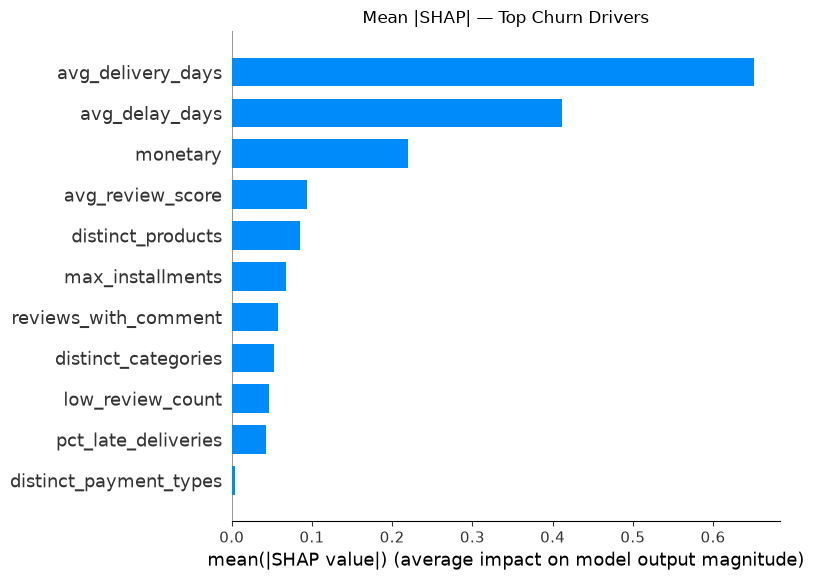

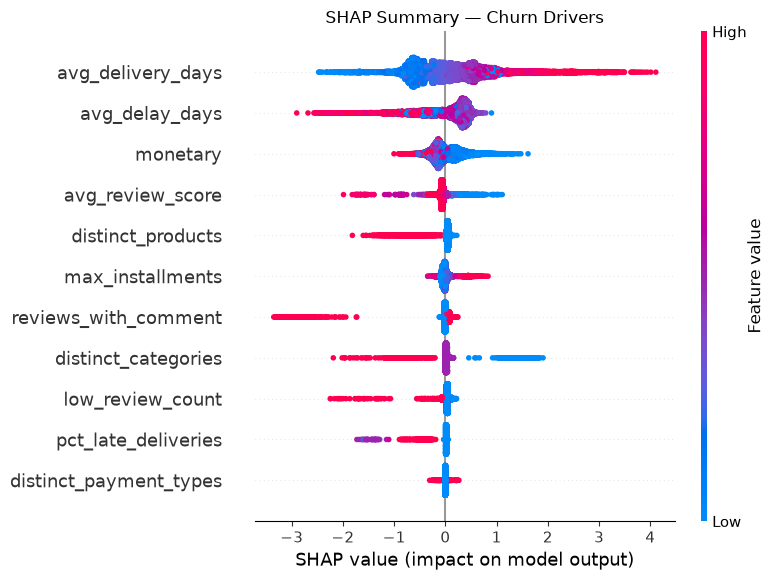


Top 5 Churn Drivers:
          feature  mean_abs_shap
avg_delivery_days       0.650885
   avg_delay_days       0.411316
         monetary       0.219309
 avg_review_score       0.094000
distinct_products       0.085074


In [14]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# SHAP on XGBoost
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_te)

# Plot 1: Feature importance bar chart
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_te, plot_type='bar', show=False)
plt.title("Mean |SHAP| — Top Churn Drivers")
plt.tight_layout()
plt.savefig("../docs/shap_bar.png", dpi=120)
plt.show()

# Plot 2: Beeswarm (shows direction of impact)
shap.summary_plot(shap_values, X_te, show=False)
plt.title("SHAP Summary — Churn Drivers")
plt.tight_layout()
plt.savefig("../docs/shap_summary.png", dpi=120)
plt.show()

# Top 5 features
mean_shap = pd.DataFrame({
    'feature':       X_te.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("\nTop 5 Churn Drivers:")
print(mean_shap.head(5).to_string(index=False))

In [15]:
import pickle, json
from pathlib import Path

Path("../models/artifacts").mkdir(parents=True, exist_ok=True)

# Save XGBoost model
with open("../models/artifacts/churn_model_xgb.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

# Save feature list
with open("../models/artifacts/feature_cols.json", "w") as f:
    json.dump(behavioral_features, f)

# Save metrics
metrics = {
    "model": "XGBoost_behavioral",
    "roc_auc": xgb_m['roc_auc'],
    "pr_auc":  xgb_m['pr_auc'],
    "f1":      xgb_m['f1'],
    "features": behavioral_features,
    "top_shap_features": mean_shap.head(5)['feature'].tolist()
}
with open("../models/artifacts/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("✓ Model saved!")
print(json.dumps(metrics, indent=2))

✓ Model saved!
{
  "model": "XGBoost_behavioral",
  "roc_auc": 0.7506,
  "pr_auc": 0.8473,
  "f1": 0.7595,
  "features": [
    "monetary",
    "avg_review_score",
    "low_review_count",
    "reviews_with_comment",
    "avg_delivery_days",
    "avg_delay_days",
    "pct_late_deliveries",
    "distinct_categories",
    "distinct_products",
    "max_installments",
    "distinct_payment_types"
  ],
  "top_shap_features": [
    "avg_delivery_days",
    "avg_delay_days",
    "monetary",
    "avg_review_score",
    "distinct_products"
  ]
}
